In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
movies = pd.read_csv(r'C:\Users\Nishant Lal\Desktop\Python\Projects\OTT\tmdb_5000_movies.csv')
credits = pd.read_csv(r'C:\Users\Nishant Lal\Desktop\Python\Projects\OTT\tmdb_5000_credits.csv')

In [7]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


In [8]:
credits.head(1)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [9]:
movies.shape

(4803, 20)

In [10]:
credits.shape

(4803, 4)

In [12]:
movies=movies.merge(credits, on='title')

In [13]:
movies.shape

(4809, 23)

In [14]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [15]:
movies=movies[['movie_id','title','overview','genres','keywords','cast','crew']]

In [16]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [17]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4809 non-null   int64 
 1   title     4809 non-null   object
 2   overview  4806 non-null   object
 3   genres    4809 non-null   object
 4   keywords  4809 non-null   object
 5   cast      4809 non-null   object
 6   crew      4809 non-null   object
dtypes: int64(1), object(6)
memory usage: 263.1+ KB


In [18]:
movies.isnull().sum()

movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64

In [19]:
movies.dropna(inplace=True)

In [20]:
movies.duplicated().sum()

np.int64(0)

In [21]:
movies.iloc[0].genres

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [22]:
import ast

def convert(obj):
    L = []
    for i in ast.literal_eval(obj):
        L.append(i['name'])
    return L

In [23]:
movies['genres'] = movies['genres'].apply(convert)

In [24]:
movies['keywords'] = movies['keywords'].apply(convert)

In [25]:
movies['cast'][0]

'[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_id": 25, "character": "Dr. Grace Augustine", "credit_id": "52fe48009251416c750aca39", "gender": 1, "id": 10205, "name": "Sigourney Weaver", "order": 2}, {"cast_id": 4, "character": "Col. Quaritch", "credit_id": "52fe48009251416c750ac9cf", "gender": 2, "id": 32747, "name": "Stephen Lang", "order": 3}, {"cast_id": 5, "character": "Trudy Chacon", "credit_id": "52fe48009251416c750ac9d3", "gender": 1, "id": 17647, "name": "Michelle Rodriguez", "order": 4}, {"cast_id": 8, "character": "Selfridge", "credit_id": "52fe48009251416c750ac9e1", "gender": 2, "id": 1771, "name": "Giovanni Ribisi", "order": 5}, {"cast_id": 7, "character": "Norm Spellman", "credit_id": "52fe48009251416c750ac9dd", "gender": 

In [26]:
import ast

def convert3(obj):
    L = []
    counter = 0

    for i in ast.literal_eval(obj):
        if counter != 3:
            L.append(i['name'])
            counter += 1
        else:
            break

    return L

In [27]:
movies['cast'] = movies['cast'].apply(convert3)

In [28]:
movies['crew'][0]

'[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Cameron"},

In [29]:
import ast

def fetch_director(obj):
    L = []

    for i in ast.literal_eval(obj):
        if i['job'] == 'Director':
            L.append(i['name'])
            break

    return L

In [30]:
movies['crew'] = movies['crew'].apply(fetch_director)

In [31]:
movies['overview'][0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [32]:
movies['overview'] = movies['overview'].apply(lambda x:x.split())

In [33]:
movies['genres'] = movies['genres'].apply(
    lambda x:[i.replace(" ","") for i in x]
)

movies['keywords'] = movies['keywords'].apply(
    lambda x:[i.replace(" ","") for i in x]
)

movies['cast'] = movies['cast'].apply(
    lambda x:[i.replace(" ","") for i in x]
)

movies['crew'] = movies['crew'].apply(
    lambda x:[i.replace(" ","") for i in x]
)

In [34]:
movies['tags'] = movies['overview'] + movies['genres'] + \
                 movies['keywords'] + movies['cast'] + \
                 movies['crew']

In [37]:
new_df = movies[['movie_id','title','tags']].copy()

In [38]:
new_df['tags'] = new_df['tags'].apply(lambda x:" ".join(x))

In [39]:
new_df['tags'] = new_df['tags'].apply(lambda x:x.lower())

In [40]:
new_df['tags'][0]
new_df['tags'][1]

"captain barbossa, long believed to be dead, has come back to life and is headed to the edge of the earth with will turner and elizabeth swann. but nothing is quite as it seems. adventure fantasy action ocean drugabuse exoticisland eastindiatradingcompany loveofone'slife traitor shipwreck strongwoman ship alliance calypso afterlife fighter pirate swashbuckler aftercreditsstinger johnnydepp orlandobloom keiraknightley goreverbinski"

In [41]:
from sklearn.feature_extraction.text import CountVectorizer

In [42]:
cv = CountVectorizer(max_features=5000, stop_words='english')

In [43]:
vectors = cv.fit_transform(new_df['tags']).toarray()

In [44]:
vectors[0]

array([0, 0, 0, ..., 0, 0, 0], shape=(5000,))

In [46]:
cv.get_feature_names_out()

array(['000', '007', '10', ..., 'zone', 'zoo', 'zooeydeschanel'],
      shape=(5000,), dtype=object)

In [47]:
import nltk

In [48]:
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

In [49]:
ps.stem('loving')

'love'

In [50]:
def stem(text):
    y = []

    for i in text.split():
        y.append(ps.stem(i))

    return " ".join(y)

In [51]:
new_df['tags'] = new_df['tags'].apply(stem)

In [52]:
from sklearn.metrics.pairwise import cosine_similarity

In [53]:
similarity = cosine_similarity(vectors)

In [54]:
similarity[2]
similarity[0]

array([1.        , 0.08964215, 0.05976143, ..., 0.02519763, 0.02817181,
       0.        ], shape=(4806,))

In [55]:
sorted(similarity[0], reverse=True)

[np.float64(1.0000000000000002),
 np.float64(0.26089696604360174),
 np.float64(0.2581988897471611),
 np.float64(0.25302403842552984),
 np.float64(0.25110592822973776),
 np.float64(0.24944382578492943),
 np.float64(0.2439750182371333),
 np.float64(0.243599382882345),
 np.float64(0.23904572186687872),
 np.float64(0.2344036154692477),
 np.float64(0.22677868380553634),
 np.float64(0.2238868314198225),
 np.float64(0.22230800575069137),
 np.float64(0.22190115272469205),
 np.float64(0.22131333406899523),
 np.float64(0.2193633988428327),
 np.float64(0.2173253797873328),
 np.float64(0.21653278478430665),
 np.float64(0.2164218276749025),
 np.float64(0.2162249910469341),
 np.float64(0.2162249910469341),
 np.float64(0.21602468994692864),
 np.float64(0.21602468994692864),
 np.float64(0.21251185925162067),
 np.float64(0.2114722130550724),
 np.float64(0.21147221305507238),
 np.float64(0.21096325392232296),
 np.float64(0.20597146021777488),
 np.float64(0.20291986247835692),
 np.float64(0.2028370211348

In [56]:
list(enumerate(similarity[0]))

[(0, np.float64(1.0000000000000002)),
 (1, np.float64(0.08964214570007951)),
 (2, np.float64(0.059761430466719674)),
 (3, np.float64(0.03984095364447979)),
 (4, np.float64(0.18257418583505533)),
 (5, np.float64(0.1183452670827877)),
 (6, np.float64(0.02258769757263128)),
 (7, np.float64(0.1763834207376394)),
 (8, np.float64(0.061721339984836754)),
 (9, np.float64(0.07644707871564382)),
 (10, np.float64(0.11769797726729993)),
 (11, np.float64(0.081199794294115)),
 (12, np.float64(0.09583148474999097)),
 (13, np.float64(0.04733810683311508)),
 (14, np.float64(0.11428571428571427)),
 (15, np.float64(0.05096471914376255)),
 (16, np.float64(0.08226127456606226)),
 (17, np.float64(0.15026857675938213)),
 (18, np.float64(0.1129384878631564)),
 (19, np.float64(0.08728715609439693)),
 (20, np.float64(0.058167505074711086)),
 (21, np.float64(0.09583148474999097)),
 (22, np.float64(0.07049073768502413)),
 (23, np.float64(0.09583148474999097)),
 (24, np.float64(0.0563436169819011)),
 (25, np.float

In [57]:
def recommend(movie):
    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[movie_index]

    movies_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x:x[1]
    )[1:6]

    for i in movies_list:
        print(new_df.iloc[i[0]].title)

In [58]:
recommend('Avatar')

Titan A.E.
Small Soldiers
Independence Day
Ender's Game
Aliens vs Predator: Requiem


In [59]:
new_df.iloc[539].title

'Titan A.E.'

In [60]:
new_df[new_df['title'] == "Batman Begins"].index[0]

np.int64(119)

In [61]:
import pickle

In [62]:
pickle.dump(new_df.to_dict(), open('movie_dict.pkl', 'wb'))

In [63]:
pickle.dump(similarity, open('similarity.pkl', 'wb'))

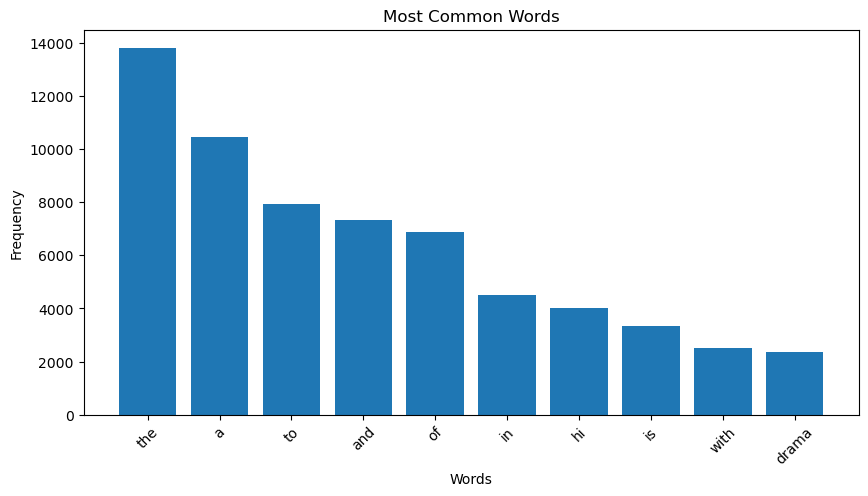

In [66]:
from collections import Counter

words = Counter(
    " ".join(new_df['tags']).split()
)

common_words = words.most_common(10)

x = [i[0] for i in common_words]
y = [i[1] for i in common_words]

plt.figure(figsize=(10,5))

plt.bar(x,y)

plt.title("Most Common Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

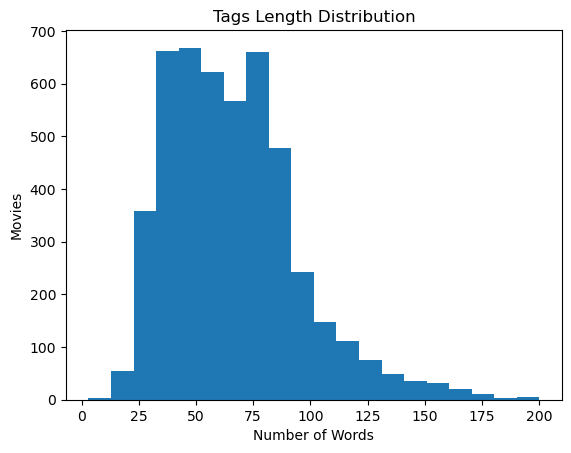

In [67]:
tag_length = new_df['tags'].apply(
    lambda x: len(x.split())
)

plt.hist(tag_length, bins=20)

plt.title("Tags Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Movies")

plt.show()

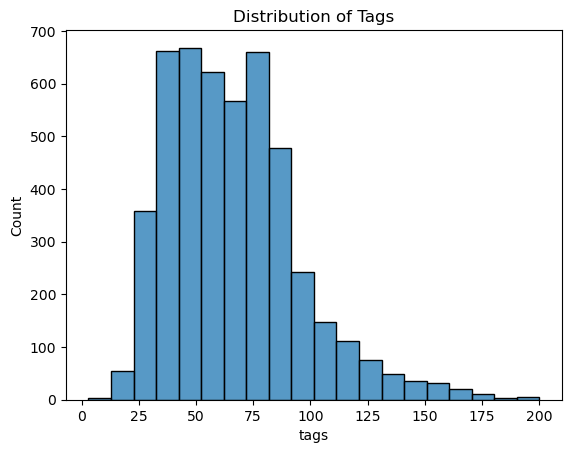

In [68]:
sns.histplot(
    new_df['tags'].apply(
        lambda x: len(x.split())
    ),
    bins=20
)

plt.title("Distribution of Tags")

plt.show()

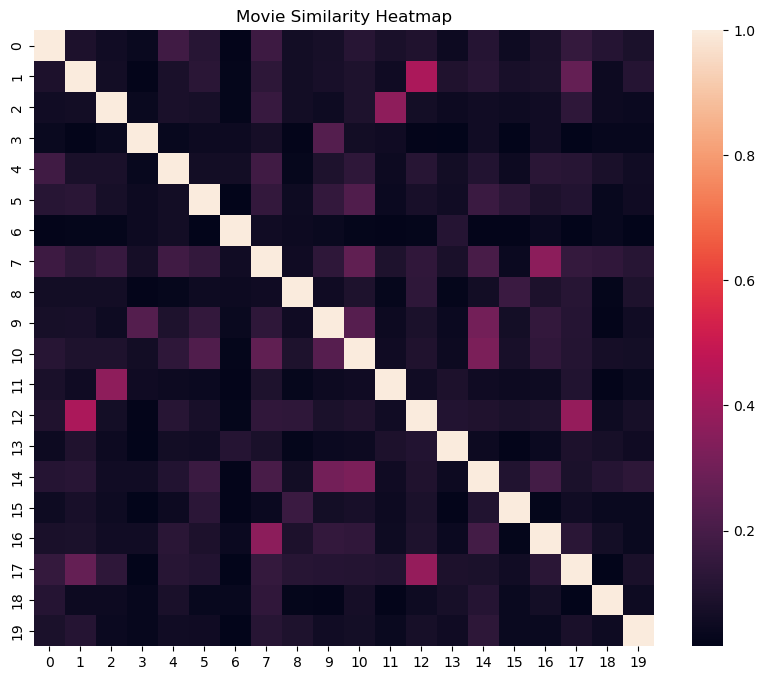

In [69]:
plt.figure(figsize=(10,8))

sns.heatmap(similarity[:20,:20])

plt.title("Movie Similarity Heatmap")

plt.show()

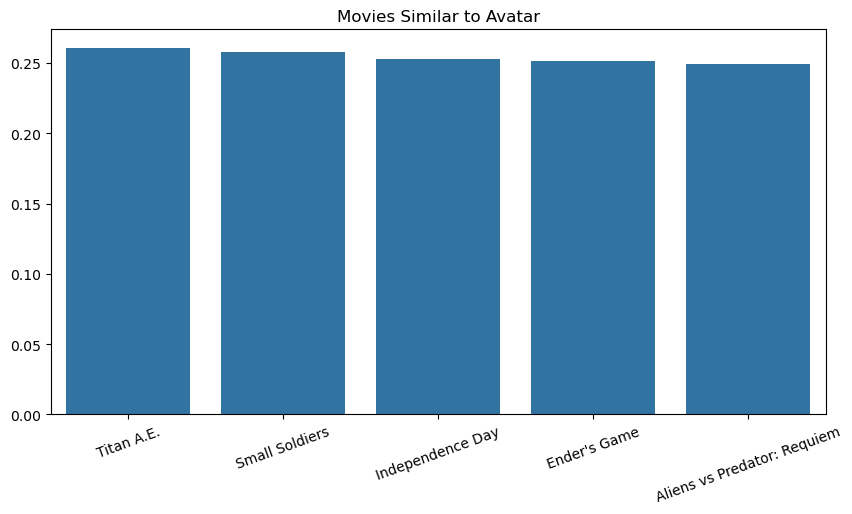

In [70]:
movie_index = new_df[
    new_df['title'] == 'Avatar'
].index[0]

distances = similarity[movie_index]

movies_list = sorted(
    list(enumerate(distances)),
    reverse=True,
    key=lambda x:x[1]
)[1:6]

movie_names = []
scores = []

for i in movies_list:
    movie_names.append(
        new_df.iloc[i[0]].title
    )

    scores.append(i[1])

plt.figure(figsize=(10,5))

sns.barplot(
    x=movie_names,
    y=scores
)

plt.title("Movies Similar to Avatar")

plt.xticks(rotation=20)

plt.show()

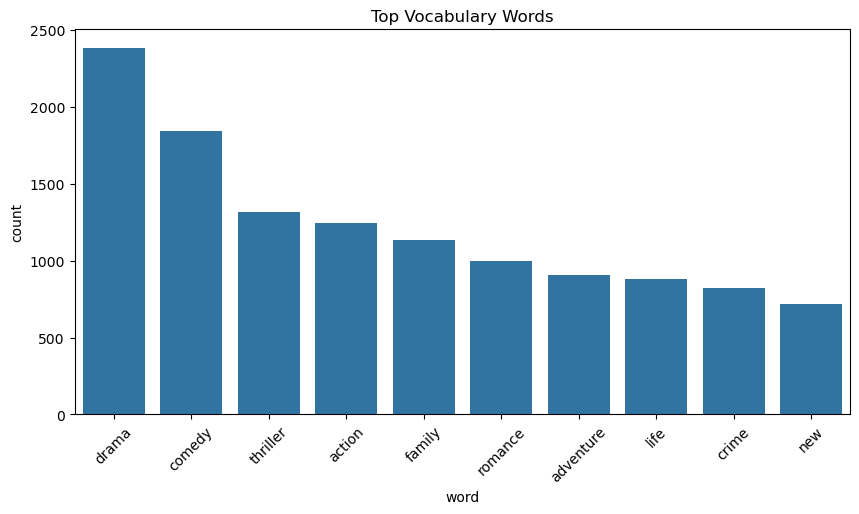

In [71]:
vocab = cv.get_feature_names_out()

word_count = vectors.sum(axis=0)

freq_df = pd.DataFrame({
    'word': vocab,
    'count': word_count
})

top_words = freq_df.sort_values(
    by='count',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_words['word'],
    y=top_words['count']
)

plt.title("Top Vocabulary Words")

plt.xticks(rotation=45)

plt.show()

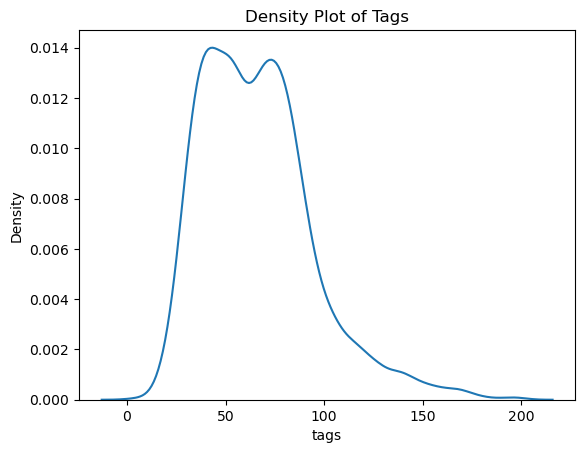

In [72]:
tag_length = new_df['tags'].apply(
    lambda x: len(x.split())
)

sns.kdeplot(tag_length)

plt.title("Density Plot of Tags")

plt.show()

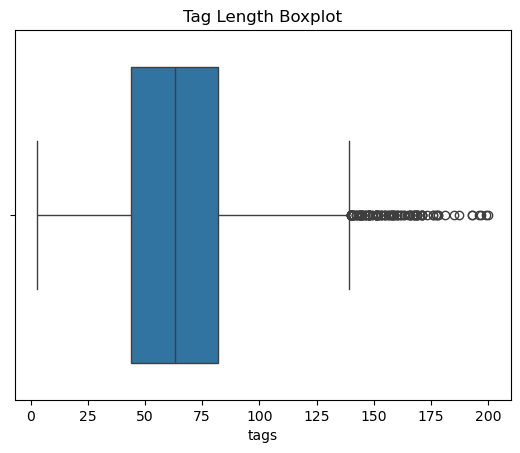

In [73]:
tag_length = new_df['tags'].apply(
    lambda x: len(x.split())
)

sns.boxplot(x=tag_length)

plt.title("Tag Length Boxplot")

plt.show()

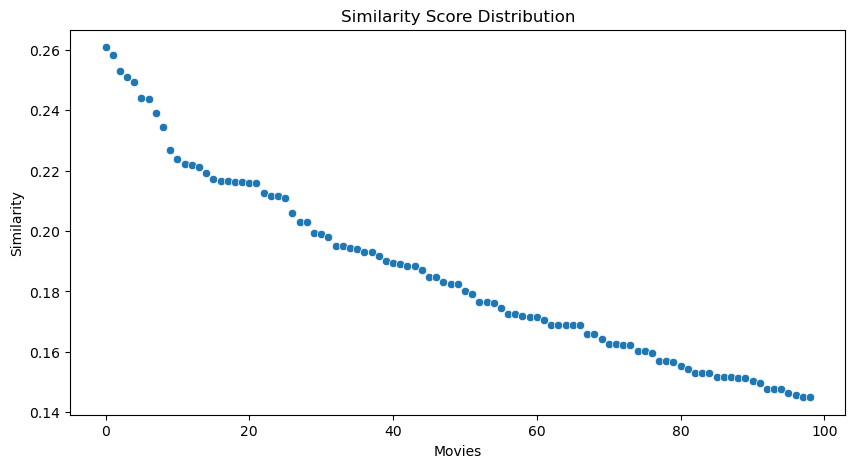

In [74]:
scores = sorted(
    similarity[0],
    reverse=True
)[1:100]

x = range(len(scores))

plt.figure(figsize=(10,5))

sns.scatterplot(
    x=x,
    y=scores
)

plt.title("Similarity Score Distribution")

plt.xlabel("Movies")
plt.ylabel("Similarity")

plt.show()

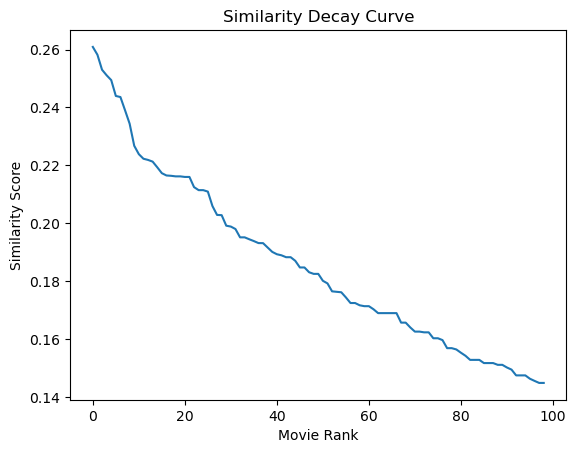

In [75]:
scores = sorted(
    similarity[0],
    reverse=True
)[1:100]

plt.plot(scores)

plt.title("Similarity Decay Curve")

plt.xlabel("Movie Rank")
plt.ylabel("Similarity Score")

plt.show()